# Aufgabenstellung
1. Bauen Sie eine Reihenschaltung bestehend aus drei Widerständen mit unterschiedlichen Widerstandswerten auf. Legen Sie eine Spannung geeigneter Größe an. Messen Sie Spannungen und Ströme. Vergleichen Sie mit Ihren Vorhersagen. Wiederholen Sie die Messungen an einer Parallelschaltung bestehend aus drei Widerständen.
2. Bauen Sie einen Spannungsteiler auf und messen Sie die Spannung über den zweiten Widerstand für unterschiedliche Lastwiderstände. Stellen Sie die Daten graphisch dar und vergleichen Sie mit Ihren Vorhersagen.
3. Bauen Sie eine Wheatstone-Brücke auf. Legen Sie eine Spannung geeigneter Größe an. Messen Sie die Brückenspannung als Funktion des Widerstandswerts eines variablen Widerstands in einem Brückenarm. Stellen Sie die Daten graphisch dar und vergleichen Sie mit Ihren Vorhersagen.
4. Bauen Sie einen Hoch- oder Tiefpass auf. Messen Sie mit einem Oszilloskop die Transferfunktion als Funktion der Frequenz. Stellen Sie die Daten graphisch dar und vergleichen Sie mit Ihren Vorhersagen.

# 1. Aufgabe
In Aufgabe 1 wurden zwei Schaltungen aufgebaut: eine Reihenschaltung und eine Parallelschaltung von Widerständen. Die Spannungen und Ströme wurden gemessen und mit den Vorhersagen verglichen. Für die beide Schaltungen wurde eine gleichstrom Spannung von 5V angelegt. Für die Wiederstände wurden die Werte 100 Ohm. 200 Ohm und 997 Ohm gewählt.
## Theoretische Grundlagen für Aufgabe 1
Da wie in Aufgabe eins sehr einfache Schaltungen haben werden nur die Grundlagen der Kirchhoff'schen Regeln und die Ohm'sche Gesetz benötigt.
Es gibt zwei Kirchhoff'sche Regeln. die Knotenregel und die Maschenregel die dem Ernergieerhaltungssatz folgen. Die Knotenregel besagt das die Summer der Strome gleich 0 ist. Es geht also in einer idalen Masche kein Strom verloren noch wird Strom kreiert.
$$\sum_i{I_i}=0$${#eq-kirchhoffsches-gesetzt1}
Während die Maschenregel besagt das die Summe der Spannungen in einer Masche gleich 0 ist.
$$\sum_i{U_i}=0$${#eq-kirchhoffsches-gesetzt2}
Das Ohm'sche Gesetz beschreibt den Zusammenhang zwischen Spannung. Strom und Widerstand.
$$U=R I$${#eq-ohmgesetz}


## Reihenschaltung
Im experiment wurde wie in folgender Abbildung aufgebaut. Dabei wurde der Wiederstand, für die drei Widerstände notiert und die Spannung über jeden einzelnen Wiederstand gemessen. Zusätzlich wurde die Eingagnsspannung $U_E$ über ein weiters digital Multimeter abgelesen. Auch der Strom wurde Stichprobenweise gemessen.
![Reihenschaltung im Experiment](./Bilder/Reihenschaltung.png)

Folgende Daten wurden gemessen:
| Widerstand ($\Omega$) | Spannung über Wiederstand $U_W$ (V) | Strom $I$ (mA) | Eingangsspannung $U_E$ (V) | 
|-----------------------|------------------------|------------|----------------------|
| 997                   | 3.77                    | -          | 4.98                    |
| 200                   | 0.75                    | $R_1$ über $R_2$: 3.75          | 4.99                    |
| 100                   | 0.38                    | $R_2$ über $R_3$: 3.76          | 4.99                    |
: Tabelle der Messwerte der Reihenschaltung

Bei der Auswertung der Daten wie man in [Abbildung @fig-reihe] sehen kann, kommt man beim Curve Fit auf $\approx3.78A$ was in der Nähe des gemessenen Wertes des Stroms von 3.75A bzw. 3.76A ist. Mittels des ohmsche Gesetzt $U=R I$ kommt man auf eine durchschnittliche Stromstärke $I \approx 3.77mA$. 

Ermittelte Stromstärke I für Reihenschaltung: 0.003783074838945133 A
Standardabweichung der Steigung: 8.4941e-06 A


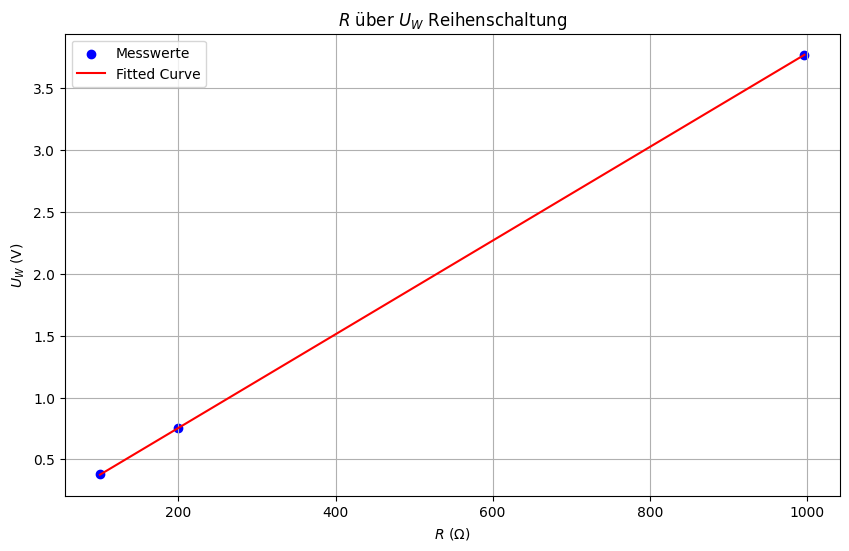

In [57]:
#| label: fig-reihe
#| fig-cap: R über U mit linearem Fit für Reihneschaltung
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load csv data
data = pd.read_csv('./Daten/Daten_Aufgabe_1_Reihe.csv')

wiederstand = data['R[Ohm]'].values
U_W = data['U_W[V]'].values

#curve-fit
def fit_func(x, a, b):
    return a * x + b
from scipy.optimize import curve_fit
params, covariance = curve_fit(fit_func, wiederstand, U_W)

print("Ermittelte Stromstärke I für Reihenschaltung:", params[0], "A")
print(f"Standardabweichung der Steigung: {np.sqrt(np.diag(covariance))[0]:.4e} A")

# Plotting the data and the fitted curve
plt.figure(figsize=(10, 6))
plt.scatter(wiederstand, U_W, label='Messwerte', color='blue')
plt.plot(wiederstand, fit_func(wiederstand, *params), label='Fitted Curve', color='red')
plt.xlabel('$R$ ($\Omega$)')
plt.ylabel('$U_W$ (V)')
plt.title('$R$ über $U_W$ Reihenschaltung')
plt.legend()
plt.grid()
plt.show()

## Parallelschaltung
Im Experiment wurde eine Parallelschaltung aufgebaut, wie in der folgenden Abbildung dargestellt. Dabei wurden drei Widerstände parallel geschaltet und jeweils die Spannung über jedem Widerstand sowie der Strom durch jeden einzelnen Widerstand gemessen. Zusätzlich wurde die Eingangsspannung $U_E$ mithilfe eines digitalen Multimeters erfasst.

![Parallelschaltung im Experiment](./Bilder/Parallelschaltung.png)

Folgende Daten wurden gemessen:

| Widerstand $R$ ($\Omega$) | Gemessene Spannung $U_W$ (V) | Eingangsspannung $U_E$ (V) | Strom $I$ (mA) |
|----------------------------|-------------------------------|-----------------------------|----------------|
| 997                        | 4.27                          | 4.97                        | 4.35           |
| 200                        | 4.19                          | 4.97                        | 20.3           |
| 100                        | 4.22                          | 4.97                        | 39.5           |
: Tabelle der Messwerte für die Parallelschaltung

Wie aus den Messwerten ersichtlich ist, ist die Spannung über allen Widerständen in einer Parallelschaltung nahezu gleich groß und entspricht in guter Näherung der Eingangsspannung $U_E$. Dies entspricht der Theorie, nach der in einer Parallelschaltung gilt $ U_W = U_E $.

Der Strom durch die einzelnen Widerstände unterscheidet sich je nach ihrem Widerstandswert gemäß dem Ohm’schen Gesetz. So ist folglich, dass kleinere Widerstände einen größeren Strom durchlassen, was in den Messwerten gut erkennbar ist. Der 100 $\Omega$-Widerstand führt den größten Strom, während durch den 997 $\Omega$-Widerstand der geringste Strom fließt.

Wie in [Abbildung @fig-parallel] kommen wir beim Curve Fit auf eine Spannung von $3.90V$ was in der Nähe des durchschnittlich gemessen Wertes von $4.22V$ ist.



Ermittelte Steigung (Spannung): 3.90 V
Standardabweichung der Steigung: 8.4941e-06 V


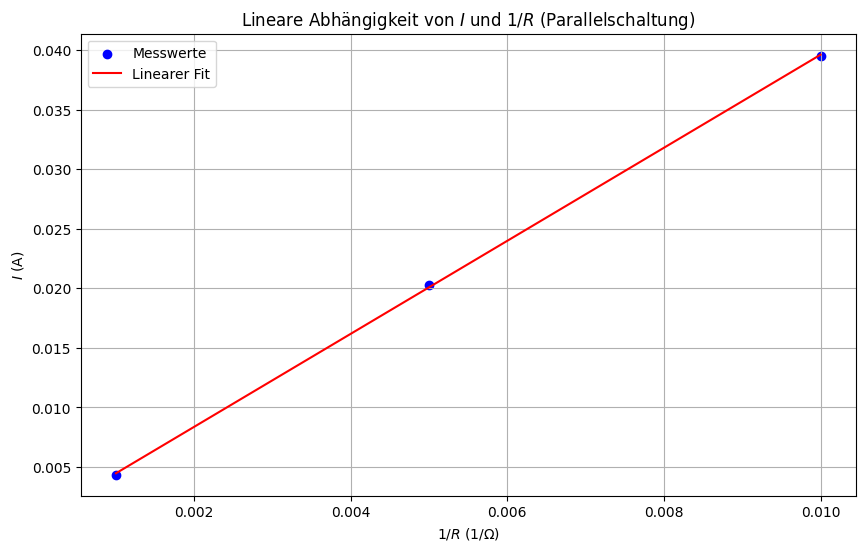

In [56]:
#| label: fig-parallel
#| fig-cap: 1/R über I mit linearem Fit für Parallelschaltung
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# CSV laden
data = pd.read_csv('./Daten/Daten_Aufgabe_1_Parallel.csv')

R = data['R[Ohm]'].values
I_mA = np.array([4.35, 20.3, 39.5])
I_A = I_mA / 1000  # in A
inv_R = 1 / R      # Leitwert in 1/Ohm

# Fit-Funktion: I = a * (1/R) + b
def fit_func(x, a, b):
    return a * x + b

params, _ = curve_fit(fit_func, inv_R, I_A)

# Fit-Parameter
a, b = params
print(f"Ermittelte Steigung (Spannung): {a:.2f} V")
# Standartabweichung
print(f"Standardabweichung der Steigung: {np.sqrt(np.diag(covariance))[0]:.4e} V")
#print(f"y-Achsenabschnitt (Offset): {b:.4e} A")

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(inv_R, I_A, label='Messwerte', color='blue')
plt.plot(inv_R, fit_func(inv_R, *params), label='Linearer Fit', color='red')
plt.xlabel('$1/R$ ($1/\\Omega$)')
plt.ylabel('$I$ (A)')
plt.title('Lineare Abhängigkeit von $I$ und $1/R$ (Parallelschaltung)')
plt.legend()
plt.grid()
plt.show()



## Fehlerbetrachtung
### Reihenschaltung
Bei der Reihenschaltung wurde die Stromstärke experimentell mittels linearem Fit der Spannungsdaten zu den Widerständen ermittelt.
Dabei betrug die Standardabweichung der Steigung $ \sigma = 8.49 \cdot 10^{-6} \,\text{A} $
Laut der Tabbelle des Multimeters beträgt die Genauigkeit im Spannungsmessbereich:

$$\pm (0.8\% + 3\,\text{Digit}) \text{ bei 20 V}$${#eq-343}

Bei einer gemessenen Spannung von 3.78 mA ergibt sich ein Messfehler von:

$$\Delta U = 0.8\% \cdot 3.78\,\text{mA} + 0.005\,\text{mA} = 0.03524\,\text{mA}$${#eq-342}

### Parallelschaltung

Bei der Parallelschaltung wurde der Strom gegen den Kehrwert des Widerstands (\$1/R\$) linear gefittet um die Spannung zu ermitteln. Die Standardabweichung der Steigung beträgt $\sigma = 8.49 \cdot 10^{-6} \,\text{V}$, was ein zuiemlich kleiner Wert ist und auf eine geringe Unsicherheit im Fit hindeutet.

Da die Stromstärke gemessen wurde, kann der Messfehler für die Stromsträke wie folgt berechnet werden. Dafür wird aus der [Fehlertabelle](#fig-fehlertabelle) des Multimeters der Fehler für den Strommessbereich herangezogen:

$$\pm (1.2\% + 4\,\text{Digit})$${#eq-3425}

Beispielhaft wird hierfür 39.5 mA als Strom durch den 100 $\Omega$ Widerstand betrachtet. Der Messfehler ergibt sich zu:

$$\Delta I = 1.2\% \cdot 39.5\,\text{mA} + 0.004\,\text{mA} = 0.478\,\text{mA}$${#eq-34244}

Zudem galt im generellen für alle Experimente, dass ein idealer Stromkreis angenommen wurde, was bedeutet, dass keine parasitären Widerstände oder Induktivitäten berücksichtigt wurden. In der Praxis können solche Effekte jedoch die Messergebnisse beeinflussen. Jodoch ist dies in diesem Experiment nicht von Bedeutung, da die Widerstände relativ hoch sind.
